# Task 2: Laning & Overtaking with SB3 PPO — FAST track

**Training and evaluation run on the "fast" track only.** For multi-track generalization training (random track per episode, per-track evaluation report) use `task3_generalization_sb3_ppo.ipynb`.

This notebook trains a PPO agent on the newer `highway-env` / Stable-Baselines3 API, following the older Task 2 setup from `racetrack-agents` where three slower non-agent vehicles are spawned and the ego vehicle must lane-follow while overtaking.

The older DQN command used `--spawn_vehicles 3`, `--batch_size 256`, `--lr 0.00005`, `--lr_decay`, `--arch Identity`, and `--fc_layers 3`. The cells below map those ideas to SB3 PPO with a 3-layer MLP policy, linear learning-rate decay, and `other_vehicles=3` in the `racetrack-oval-v0` config.

In [1]:
# If this notebook is running in a fresh environment, install the core packages first.
# In the local repo environment you can usually leave this cell commented out.
#
# %pip install "highway-env>=1.8" "stable-baselines3[extra]>=2.0" tensorboard moviepy

from pathlib import Path
from copy import deepcopy
import base64
import os
import random

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import highway_env  # Registers highway-env environments in many versions.
import numpy as np
import torch.nn as nn
import torch

from IPython.display import HTML, display
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecEnv

# Newer gymnasium versions can register an external environment package explicitly.
# Older highway-env versions register on import, so we keep this tolerant.
try:
    gym.register_envs(highway_env)
except Exception:
    pass


c:\Users\16469\anaconda3\envs\circuit\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Experiment Config

Task 2 is represented by `other_vehicles=3`. The notebook now starts from `RacetrackEnvOval.default_config()` and overrides only the pieces that define this experiment, so future highway-env API changes are easier to absorb.

In [3]:
SEED = 42
ENV_ID = "racetrack-v0"

# Keep full training as the default. For an end-to-end notebook smoke test, run
# `FAST_DEV_RUN=1` in the process environment before executing the notebook.
FAST_DEV_RUN = False
USE_EARLY_STOP = False  # Stop training early if the evaluation reward is consistently high.

# Prefer CPU in notebooks unless a CUDA-enabled GPU is available and stable.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

EXP_ID = "sb3_ppo_cnn_full"
if FAST_DEV_RUN:
    EXP_ID += "_fast"

WORK_DIR = Path.cwd()

RUN_DIR = WORK_DIR / "runs" / EXP_ID
MODEL_DIR = RUN_DIR / "models"
BEST_MODEL_DIR = MODEL_DIR / "best"
CHECKPOINT_DIR = MODEL_DIR / "checkpoints"
LOG_DIR = RUN_DIR / "logs"
VIDEO_DIR = RUN_DIR / "videos"
TB_LOG_DIR = RUN_DIR / "tensorboard"

for directory in [MODEL_DIR, BEST_MODEL_DIR, CHECKPOINT_DIR, LOG_DIR, VIDEO_DIR, TB_LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Reproducibility: exact runs can still vary across machines/GPU kernels.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda


In [ ]:
def set_global_seeds(seed: int, fast_training: bool = True):
""
    Seed every random source that affects training.
    Call this ONCE before creating envs or model.
""
    random.seed(seed)                          # Python stdlib
    np.random.seed(seed)                       # NumPy
    torch.manual_seed(seed)                    # PyTorch CPU ops
    torch.cuda.manual_seed_all(seed)           # PyTorch GPU ops (all devices)
    os.environ["PYTHONHASHSEED"] = str(seed)   # Python hash randomisation

    # Optional: sacrifice speed for full CUDA determinism.
    # Comment out if training speed matters more than exact reproducibility.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False  # benchmark=True auto-tunes kernels
                                                 # but picks different ops each run
    if fast_training:
        # Let cuDNN find the fastest algorithm for your fixed input shapes.
        # One-time profiling cost of ~2-3 seconds at the start of training.
        # Not reproducible: two runs may produce slightly different loss curves
        # but converge to the same policy quality.
        torch.backends.cudnn.benchmark     = True
        torch.backends.cudnn.deterministic = False
    else:
        # Force deterministic algorithms throughout.
        # Reproducible: two runs with the same seed produce byte-identical results.
        # Costs 5-30% training speed depending on your CNN architecture.
        torch.backends.cudnn.benchmark     = False
        torch.backends.cudnn.deterministic = True

set_global_seeds(SEED, fast_training=not FAST_DEV_RUN)

In [5]:
from highway_env.envs import racetrack_env
from race_env import RacetrackFast
racetrack_env.RacetrackFast = RacetrackFast
gym.register(id=ENV_ID, entry_point="race_env:RacetrackFast")

c:\Users\16469\anaconda3\envs\circuit\lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment racetrack-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


## Track Shapes

All tracks available via `config["track"]` (and sampled by `"random"` during generalization training). Black lines are the corridor's outer edges — the physical walls; the light line between them is the lane divider (not a wall). Red letters mark checkpoint segment starts.


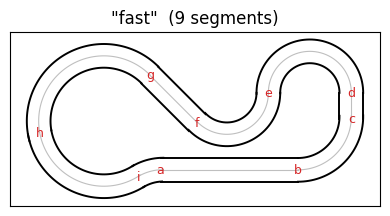

In [11]:
import matplotlib.pyplot as plt

TRACK_NAMES = ["fast"]

fig, ax = plt.subplots(1, len(TRACK_NAMES), figsize=(4 * len(TRACK_NAMES), 4))
name = TRACK_NAMES[0]
tenv = gym.make(ENV_ID, config={"track": name}).unwrapped
tenv.reset(seed=0)
graph = tenv.road.network.graph
for _from in graph:
    for _to in graph[_from]:
        lanes = graph[_from][_to]
        for k, lane in enumerate(lanes):
            s = np.linspace(0, lane.length, max(2, int(lane.length)))
            # corridor outer edges (the walls) in black, divider in grey
            edges = []
            if k == 0:
                edges.append((-lane.width / 2, "k", 1.4))
                edges.append((+lane.width / 2, "0.75", 0.8))   # divider
            if k == len(lanes) - 1:
                edges.append((+lane.width / 2, "k", 1.4))
            for lat, color, lw in edges:
                pts = np.array([lane.position(si, lat) for si in s])
                ax.plot(pts[:, 0], pts[:, 1], color=color, lw=lw)
seq = tenv.segment_sequence
for i, seg in enumerate(seq):
    lane0 = tenv.road.network.get_lane((seg, seq[(i + 1) % len(seq)], 0))
    ax.annotate(seg, lane0.position(0, 2.5), fontsize=9,
                color="tab:red", ha="center", va="center")
ax.set_title(f'"{name}"  ({len(seq)} segments)')
ax.set_aspect("equal")
ax.invert_yaxis()   # match the env's screen orientation (y points down)
ax.set_xticks([]); ax.set_yticks([])
tenv.close()
plt.tight_layout()
plt.show()


In [7]:
N_ENVS = min(8, max(1, os.cpu_count() or 1))

# ════════════════════════════════════════════════════════════════════
# Speed and step count optimisation
#
# NOTE on eval_freq units: EvalCallback counts PER-ENV steps, so the
# interval in timesteps is eval_freq × N_ENVS. It must divide the phase
# budget at least once or no best_model.zip is ever written (this is
# exactly what happened in phase 2 before: 2048 × 8 = 16,384 > 8,192).
# ════════════════════════════════════════════════════════════════════

if FAST_DEV_RUN:
    # Quick but enough to see potential: ~50k total steps.
    # Phase 1 learns forward driving; phase 2 gets enough budget to at
    # least react to the NPC and produce a valid best_model.zip.
    PHASE1_TIMESTEPS = 120_000
    PHASE2_TIMESTEPS = 16_384
    P1_N_STEPS    = 512;  P2_N_STEPS    = 512
    P1_BATCH_SIZE =  256;  P2_BATCH_SIZE =  128
    P1_N_EPOCHS   =   8;  P2_N_EPOCHS   =   8
    # ent_coef 0.10 made the policy std explode to ~1.6 (near-random
    # actions) — with a dense shaped reward, tiny entropy is enough.
    P1_ENT_COEF   = 0.02; P2_ENT_COEF   = 0.005
    P1_LR         = 2e-4; P2_LR         = 3e-4
    # every 512×2×8 = 8,192 timesteps → 4 evals in P1, 2 evals in P2
    P1_EVAL_FREQ  = P1_N_STEPS * 2
    P2_EVAL_FREQ  = P2_N_STEPS * 2
    N_EVAL_EPISODES = 2;  CHECKPOINT_FREQ = 4096

else:
    # Reduced steps — sufficient with dense rewards + fast sim
    PHASE1_TIMESTEPS = 1_000_000   # was 2_000_000
    PHASE2_TIMESTEPS = 3_000_000   # was 6_000_000

    # Shorter rollout = more frequent updates per wall-clock minute
    P1_N_STEPS    = 512
    P1_BATCH_SIZE = 256
    P1_N_EPOCHS   =  15
    P1_ENT_COEF   = 0.02
    P1_LR         = 2e-4    # slightly higher → faster convergence in phase 1

    P2_N_STEPS    = 1024    # was 2048 — more frequent updates
    P2_BATCH_SIZE = 256
    P2_N_EPOCHS   =  15
    P2_ENT_COEF   = 0.005
    P2_LR         = 1e-4

    # every 512×8×8 = 32,768 timesteps → ~30 evals over phase 1
    P1_EVAL_FREQ  = P1_N_STEPS * 8
    # every 1024×8×8 = 65,536 timesteps → ~45 evals over phase 2
    P2_EVAL_FREQ  = P2_N_STEPS * 8

    N_EVAL_EPISODES = 5
    CHECKPOINT_FREQ = P2_N_STEPS * 20  # every 20 rollouts

# Slightly smaller clip range helps learning stay stable when the action space grows.
CLIP_RANGE = 0.15

# Stronger discounting and GAE smoothing can improve horizon-aware lane-following and overtaking behavior.
GAMMA = 0.99
GAE_LAMBDA = 0.98
MAX_GRAD_NORM = 0.5


## Build Training and Evaluation Environments

SB3 trains on vectorized environments. `DummyVecEnv` is the safest default inside notebooks on Windows. For longer command-line runs, set `USE_SUBPROC = True`.

In [ ]:
class EnvFactory:
""
    Picklable factory with explicit render_mode control.
    render_mode is always None during training.
    Pass render_mode="rgb_array" only for recording envs.
""
    def __init__(self, config: dict, render_mode: str | None = None):
        self.config      = config
        self.render_mode = render_mode   # None during training, always

    def __call__(self) -> gym.Env:
        return gym.make(
            ENV_ID,
            config      = self.config,
            render_mode = self.render_mode,  # explicitly passed, never hardcoded
        )

In [13]:
# Phase 1: no NPCs, learn basic forward motion
phase1_config = RacetrackFast.default_config().copy()
phase1_config["other_vehicles"] = 0
# "random" resamples the track (fast circuit / oval) every episode, so the
# policy must learn reactive lane-following instead of memorizing one layout
phase1_config["track"] = "fast"

# Phase 2: add NPCs for avoidance
phase2_config = RacetrackFast.default_config().copy()
phase2_config["other_vehicles"] = 1
phase2_config["track"] = "fast"

# Eval: no NPCs (cleaner signal), generalization probe on the oval
eval_config = RacetrackFast.default_config().copy()
eval_config["other_vehicles"] = 0
eval_config["terminate_off_road"]= True
eval_config["track"] = "fast"


### Reward yardstick

Translates `eval/mean_reward` into laps: a lap has a concrete, computable value, so you can tell from TensorBoard alone whether the policy laps, loiters, or crashes early.


In [14]:
# What is a lap worth? Judge training progress against these numbers.
probe = gym.make(ENV_ID, config=eval_config).unwrapped
probe.reset(seed=0)
seq = probe.segment_sequence
lap_m = sum(probe.road.network.get_lane((a, b, 0)).length
            for a, b in zip(seq, seq[1:] + seq[:1]))
v_max = eval_config["speed_limit"]
steps_per_lap = lap_m / v_max * eval_config["policy_frequency"]
r_drive = 0.93   # measured per-step reward while lapping at the speed limit
r_idle  = 0.53   # measured per-step reward of a policy that just idles
ep_steps = eval_config["duration"] * eval_config["policy_frequency"]
print(f"track '{probe.active_track}': lap ≈ {lap_m:.0f} m ≈ {steps_per_lap:.0f} steps at {v_max:.0f} m/s")
print(f"return per lap        ≈ {steps_per_lap * r_drive:.0f}")
print(f"full-episode ceiling  ≈ {ep_steps * r_drive:.0f}   ({ep_steps:.0f} steps of clean driving)")
print(f"idle/loiter plateau   ≈ {ep_steps * r_idle:.0f}   (policy alive but not driving)")
print(f"early-termination     ≪ {ep_steps * r_idle:.0f}   (crashes/wall-stuck cut the episode)")
print()
print("Reading eval/mean_reward during training:")
print(f"  stuck near {ep_steps * r_idle:.0f} → loitering local optimum, not a step-budget problem")
print(f"  climbing past {ep_steps * r_idle:.0f} toward {ep_steps * r_drive:.0f} → lapping has emerged")
probe.close()


track 'fast': lap ≈ 349 m ≈ 109 steps at 16 m/s
return per lap        ≈ 101
full-episode ceiling  ≈ 3720   (4000 steps of clean driving)
idle/loiter plateau   ≈ 2120   (policy alive but not driving)
early-termination     ≪ 2120   (crashes/wall-stuck cut the episode)

Reading eval/mean_reward during training:
  stuck near 2120 → loitering local optimum, not a step-budget problem
  climbing past 2120 toward 3720 → lapping has emerged


In [ ]:
def make_fresh_eval_env(seed: int) -> VecEnv:
""
    Always creates a brand-new VecEnv for evaluation.
    Never reuse an eval_env across phases — stale episode state
    causes EvalCallback to get inconsistent rewards.
""
    return make_vec_env(
        EnvFactory(eval_config, render_mode=None),
        n_envs      = 1,
        seed        = seed,
        vec_env_cls = DummyVecEnv,
    )

In [16]:
phase1_train_env = make_vec_env(
    EnvFactory(phase1_config, render_mode=None),
    n_envs      = N_ENVS,
    seed        = SEED,
    vec_env_cls = DummyVecEnv,
)

phase2_train_env = make_vec_env(
    EnvFactory(phase2_config, render_mode=None),
    n_envs      = N_ENVS,
    seed        = SEED,
    vec_env_cls = DummyVecEnv,
)

## Define PPO

The PPO policy uses a 3-layer actor and critic MLP, matching the spirit of `--arch Identity --fc_layers 3` from the older code: flatten the occupancy grid, then learn dense policy/value heads. Comments below explain every model setting that differs from SB3 defaults or maps to the older command.

In [ ]:
class RacetrackCNN(BaseFeaturesExtractor):
""
    Lightweight CNN for the 10×12×12 OccupancyGrid.
    Grid is ego-aligned and forward-biased (27 m ahead / 9 m behind,
    ±18 m lateral, 3 m cells) — ego sits at cell (3, 6).
    Input:  [batch, 10, 12, 12]
    Output: flat feature vector of size features_dim
""
    def __init__(self, observation_space, features_dim=512):
        super().__init__(observation_space, features_dim)
        n_channels = observation_space.shape[0]  # 10
        self.cnn = nn.Sequential(
            nn.Conv2d(n_channels, 64, kernel_size=3, padding=1),  # → [64, 12, 12]
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),          # → [128, 12, 12]
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2),            # → [256, 5, 5]
            nn.ReLU(),
            nn.Flatten(),                                           # → 6400
            nn.Linear(256 * 5 * 5, features_dim),
            nn.ReLU(),
        )

    def forward(self, obs):
        return self.cnn(obs.float())

policy_kwargs = dict(
    features_extractor_class=RacetrackCNN,
    features_extractor_kwargs=dict(features_dim=512),
    net_arch=dict(pi=[256, 128], vf=[256, 128]),  # separate actor/critic heads
)

In [ ]:
def linear_schedule(initial_value):
""SB3 schedule: progress_remaining moves from 1.0 to 0.0 during training."""
    def schedule(progress_remaining):
        return progress_remaining * initial_value
    return schedule

In [19]:
phase1_model = PPO(
    policy          = "CnnPolicy",
    env             = phase1_train_env,
    learning_rate   = linear_schedule(P1_LR),
    n_steps         = P1_N_STEPS,
    batch_size      = P1_BATCH_SIZE,
    n_epochs        = P1_N_EPOCHS,
    gamma           = GAMMA,
    gae_lambda      = GAE_LAMBDA,
    clip_range      = CLIP_RANGE,
    ent_coef        = P1_ENT_COEF,
    max_grad_norm   = MAX_GRAD_NORM,
    policy_kwargs   = policy_kwargs,
    tensorboard_log = str(TB_LOG_DIR),
    seed            = SEED,
    verbose         = 1,
    device          = DEVICE,
)

# SB3 uses orthogonal init with scale 0.01 — mean output is near 0
# Manually shift the throttle bias toward +0.5 so initial acceleration
# maps to lmap(0.5, [-1,1], [-3,6]) = 3.75 m/s² instead of 1.5 m/s²
with torch.no_grad():
    # phase1_model.policy.action_net.bias.zero_()
    
    action_bias = phase1_model.policy.action_net.bias
    action_bias[0] = 0.40   # throttle dimension → biased forward
    action_bias[1] = 0.0    # steering dimension → neutral

Using cuda device


## Train and Save the Best Model

`EvalCallback` periodically runs deterministic evaluations and writes the best model to disk. TensorBoard logs are stored under `runs/sb3_ppo_task2_laning_overtaking/logs`.

In [ ]:
# Start TensorBoard in the notebook while training is running.
# This opens the log directory in a background server and prints the local URL.
#
%load_ext tensorboard
%tensorboard --logdir {TB_LOG_DIR} --port 6006

# If the magic above is not available, you can also launch a standalone server from a terminal:
# tensorboard --logdir "runs/sb3_ppo_laning_overtaking_richocc_throttle_fastdev/tensorboard" --host 127.0.0.1 --port 6006


In [ ]:
class PhaseEarlyStop(BaseCallback):
""
    Stop a training phase when eval reward has not improved
    for `patience` consecutive evaluations.
    Reads EvalCallback's logged value — no per-step signal.
""
    def __init__(self, patience: int = 5, min_delta: float = 0.5, verbose: int = 1):
        super().__init__(verbose)
        self.patience   = patience
        self.min_delta  = min_delta
        self._best      = -np.inf
        self._no_improv = 0
        self._last_val  = None

    def _on_step(self) -> bool:
        val = self.logger.name_to_value.get("eval/mean_reward", None)
        if val is None or val == self._last_val:
            return True
        self._last_val = val

        if val > self._best + self.min_delta:
            self._best      = val
            self._no_improv = 0
            if self.verbose:
                print(f"[EarlyStop] Improved → {self._best:.3f}")
        else:
            self._no_improv += 1
            if self.verbose:
                print(f"[EarlyStop] No improvement {self._no_improv}/{self.patience} "
                      f"(current={val:.3f} best={self._best:.3f})")

        if self._no_improv >= self.patience:
            if self.verbose:
                print(f"[EarlyStop] Stopping at step {self.num_timesteps}")
            return False
        return True

In [21]:
def make_callbacks(phase_label: str, n_steps: int, eval_freq: int):
    fresh_eval_env = make_vec_env(
        EnvFactory(eval_config, render_mode=None),
        n_envs=1, seed=SEED + 10_000, vec_env_cls=DummyVecEnv,
    )
    save_path = BEST_MODEL_DIR / phase_label
    save_path.mkdir(parents=True, exist_ok=True)

    eval_cb = EvalCallback(
        fresh_eval_env,
        best_model_save_path = str(save_path),
        log_path             = str(LOG_DIR / "eval" / phase_label),
        eval_freq            = eval_freq,
        n_eval_episodes      = N_EVAL_EPISODES,
        deterministic        = True,
        render               = False,
        verbose              = 0,
    )
    ckpt_cb = CheckpointCallback(
        save_freq   = CHECKPOINT_FREQ,
        save_path   = str(CHECKPOINT_DIR / phase_label),
        name_prefix = f"ppo_{phase_label}",
        verbose     = 0,
    )
    callbacks = [eval_cb, ckpt_cb]

    if USE_EARLY_STOP and not FAST_DEV_RUN:
        # Phase 1: stop quickly once driving is learned (patience=5)
        # Phase 2: allow more exploration before giving up (patience=8)
        patience = 5 if phase_label == "phase1" else 8
        callbacks.append(
            PhaseEarlyStop(patience=patience, min_delta=0.5, verbose=1)
        )

    return callbacks, fresh_eval_env

In [ ]:
phase1_callbacks, phase1_eval_env = make_callbacks(
phase1", P1_N_STEPS, P1_EVAL_FREQ
)

In [ ]:
phase1_model.learn(
    total_timesteps = PHASE1_TIMESTEPS,
    callback        = phase1_callbacks,
    tb_log_name     = "phase1",
    progress_bar    = True,
)

In [ ]:
phase1_path = MODEL_DIR / "phase1.zip"
phase1_model.save(str(phase1_path))
print(f"Phase 1 saved → {phase1_path}")
phase1_eval_env.close()

In [ ]:
best_p1 = BEST_MODEL_DIR / "phase1" / "best_model.zip"
print(f"\nPhase 1 best model exists: {best_p1.exists()} → {best_p1}")
assert best_p1.exists(), (
Phase 1 best_model.zip was NOT saved. "
Check that EvalCallback printed eval results above. "
    f"Expected path: {best_p1}"
)


Phase 1 best model exists: True → c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\models\best\phase1\best_model.zip


In [ ]:
eval_config["other_vehicles"] = 1
phase2_callbacks, phase2_eval_env = make_callbacks(
phase2", P2_N_STEPS, P2_EVAL_FREQ
)

In [ ]:
model = PPO.load(
    str(phase1_path),
    env            = phase2_train_env,
    device         = DEVICE,

    # custom_objects overrides saved hyperparameters and
    # triggers a full _setup_model() reinitialization
    custom_objects = {
        # CONSTANT lr here, not linear_schedule: with
        # reset_num_timesteps=False the schedule's progress_remaining
        # starts at PHASE2/(PHASE1+PHASE2), so phase 2 previously began
        # at ~10% of P2_LR and hit ~0 almost immediately (the log showed
        # learning_rate 1.1e-05).
    learning_rate": P2_LR,
    n_steps":       P2_N_STEPS,               # ← buffer reallocated here
    batch_size":    P2_BATCH_SIZE,
    n_epochs":      P2_N_EPOCHS,
    ent_coef":      P2_ENT_COEF,              # lower entropy: exploit more
    clip_range":    CLIP_RANGE,
    gamma":         GAMMA,
    gae_lambda":    GAE_LAMBDA,
    max_grad_norm": MAX_GRAD_NORM,
    },
)

In [28]:
# Verify buffer was correctly reallocated
assert model.rollout_buffer.buffer_size == P2_N_STEPS, (
    f"Buffer size mismatch: expected {P2_N_STEPS}, "
    f"got {model.rollout_buffer.buffer_size}. "
    f"custom_objects may not have applied correctly."
)
print(f"Buffer size confirmed: {model.rollout_buffer.buffer_size}")

Buffer size confirmed: 1024


In [25]:
model.learn(
    total_timesteps     = PHASE2_TIMESTEPS,
    callback            = phase2_callbacks,
    tb_log_name         = "phase2",
    reset_num_timesteps = False,   # continue global step counter
    progress_bar        = True,
)

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 500        |
|    mean_reward          | 391        |
| time/                   |            |
|    total_timesteps      | 2838528    |
| train/                  |            |
|    approx_kl            | 0.37077793 |
|    clip_fraction        | 0.715      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.117      |
|    explained_variance   | 0.34881306 |
|    learning_rate        | 0.0001     |
|    loss                 | 12.6       |
|    n_updates            | 7020       |
|    policy_gradient_loss | 0.0208     |
|    std                  | 0.229      |
|    value_loss           | 58         |
----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 644      |
|    ep_rew_mean     | 504      |
| time/              |          |
|    fps             | 48       |
|    iterations  

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 624        |
|    ep_rew_mean          | 486        |
| time/                   |            |
|    fps                  | 47         |
|    iterations           | 225        |
|    time_elapsed         | 38559      |
|    total_timesteps      | 2846720    |
| train/                  |            |
|    approx_kl            | 0.46631092 |
|    clip_fraction        | 0.71       |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.114      |
|    explained_variance   | 0.28682697 |
|    learning_rate        | 0.0001     |
|    loss                 | 9.13       |
|    n_updates            | 7035       |
|    policy_gradient_loss | 0.00451    |
|    std                  | 0.228      |
|    value_loss           | 46.2       |
----------------------------------------


---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 626       |
|    ep_rew_mean          | 490       |
| time/                   |           |
|    fps                  | 46        |
|    iterations           | 226       |
|    time_elapsed         | 39448     |
|    total_timesteps      | 2854912   |
| train/                  |           |
|    approx_kl            | 0.5094176 |
|    clip_fraction        | 0.738     |
|    clip_range           | 0.15      |
|    entropy_loss         | 0.123     |
|    explained_variance   | 0.2845676 |
|    learning_rate        | 0.0001    |
|    loss                 | 4.6       |
|    n_updates            | 7050      |
|    policy_gradient_loss | 0.0109    |
|    std                  | 0.227     |
|    value_loss           | 26.4      |
---------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 686        |
|    ep_rew_mean          | 537        |
| time/                   |            |
|    fps                  | 46         |
|    iterations           | 227        |
|    time_elapsed         | 40334      |
|    total_timesteps      | 2863104    |
| train/                  |            |
|    approx_kl            | 0.38654244 |
|    clip_fraction        | 0.723      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.131      |
|    explained_variance   | 0.3676405  |
|    learning_rate        | 0.0001     |
|    loss                 | 5.65       |
|    n_updates            | 7065       |
|    policy_gradient_loss | 0.000732   |
|    std                  | 0.226      |
|    value_loss           | 23         |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 561        |
|    ep_rew_mean          | 439        |
| time/                   |            |
|    fps                  | 44         |
|    iterations           | 229        |
|    time_elapsed         | 42083      |
|    total_timesteps      | 2879488    |
| train/                  |            |
|    approx_kl            | 0.39441955 |
|    clip_fraction        | 0.71       |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.153      |
|    explained_variance   | 0.51996726 |
|    learning_rate        | 0.0001     |
|    loss                 | 7.19       |
|    n_updates            | 7095       |
|    policy_gradient_loss | 0.00936    |
|    std                  | 0.224      |
|    value_loss           | 43.5       |
----------------------------------------


...

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 300        |
|    ep_rew_mean          | 193        |
| time/                   |            |
|    fps                  | 35         |
|    iterations           | 363        |
|    time_elapsed         | 84861      |
|    total_timesteps      | 3977216    |
| train/                  |            |
|    approx_kl            | 0.6354718  |
|    clip_fraction        | 0.757      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.742      |
|    explained_variance   | 0.45205283 |
|    learning_rate        | 0.0001     |
|    loss                 | 9.82       |
|    n_updates            | 9105       |
|    policy_gradient_loss | 0.0196     |
|    std                  | 0.167      |
|    value_loss           | 43.2       |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 287        |
|    ep_rew_mean          | 185        |
| time/                   |            |
|    fps                  | 35         |
|    iterations           | 364        |
|    time_elapsed         | 85010      |
|    total_timesteps      | 3985408    |
| train/                  |            |
|    approx_kl            | 0.65471363 |
|    clip_fraction        | 0.742      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.744      |
|    explained_variance   | 0.4139678  |
|    learning_rate        | 0.0001     |
|    loss                 | 10.3       |
|    n_updates            | 9120       |
|    policy_gradient_loss | 0.018      |
|    std                  | 0.166      |
|    value_loss           | 48.1       |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 256        |
|    ep_rew_mean          | 170        |
| time/                   |            |
|    fps                  | 35         |
|    iterations           | 365        |
|    time_elapsed         | 85158      |
|    total_timesteps      | 3993600    |
| train/                  |            |
|    approx_kl            | 0.6933925  |
|    clip_fraction        | 0.732      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.748      |
|    explained_variance   | 0.43394834 |
|    learning_rate        | 0.0001     |
|    loss                 | 11.4       |
|    n_updates            | 9135       |
|    policy_gradient_loss | 0.00852    |
|    std                  | 0.166      |
|    value_loss           | 45         |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 266        |
|    ep_rew_mean          | 174        |
| time/                   |            |
|    fps                  | 35         |
|    iterations           | 366        |
|    time_elapsed         | 85304      |
|    total_timesteps      | 4001792    |
| train/                  |            |
|    approx_kl            | 0.7212988  |
|    clip_fraction        | 0.762      |
|    clip_range           | 0.15       |
|    entropy_loss         | 0.755      |
|    explained_variance   | 0.42592973 |
|    learning_rate        | 0.0001     |
|    loss                 | 15.2       |
|    n_updates            | 9150       |
|    policy_gradient_loss | 0.0176     |
|    std                  | 0.165      |
|    value_loss           | 49.1       |
----------------------------------------


---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 270       |
|    ep_rew_mean          | 177       |
| time/                   |           |
|    fps                  | 35        |
|    iterations           | 367       |
|    time_elapsed         | 85450     |
|    total_timesteps      | 4009984   |
| train/                  |           |
|    approx_kl            | 0.7313912 |
|    clip_fraction        | 0.767     |
|    clip_range           | 0.15      |
|    entropy_loss         | 0.757     |
|    explained_variance   | 0.3226053 |
|    learning_rate        | 0.0001    |
|    loss                 | 16.1      |
|    n_updates            | 9165      |
|    policy_gradient_loss | 0.0237    |
|    std                  | 0.165     |
|    value_loss           | 43.3      |
---------------------------------------


In [ ]:
final_path = MODEL_DIR / "ppo_last.zip"
model.save(str(final_path))
print(f"Phase 2 saved → {final_path}")
phase2_eval_env.close()

In [30]:
import importlib

for module_name in ["onnx", "onnxruntime"]:
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        os.system('pip install --quiet "onnx==1.12.0" "onnxruntime==1.12.0"')

import onnx
import onnxruntime as ort

In [31]:
best_model_path = BEST_MODEL_DIR / "phase2"  / "best_model.zip"
print(f"\nPhase 2 best model exists: {best_model_path.exists()} → {best_model_path}")

last_model_path = MODEL_DIR / "ppo_last.zip"

trained_model = PPO.load(
    best_model_path if best_model_path.exists() else last_model_path,
    device="cpu",
)
trained_model.policy.eval()
trained_model.policy.to("cpu")

obs_shape = phase2_train_env.observation_space.shape      # e.g. (11, 12, 12)
dummy_obs  = torch.zeros(1, *obs_shape, dtype=torch.float32)  # [1,C,H,W]

print(f"Observation space : {obs_shape}")
print(f"Dummy input shape : {tuple(dummy_obs.shape)}")


Phase 2 best model exists: True → c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\models\best\phase2\best_model.zip
Observation space : (10, 12, 12)
Dummy input shape : (1, 10, 12, 12)


In [ ]:
class ActorOnlyWrapper(nn.Module):
""
    obs → action_mean
    Deterministic forward pass: features → mlp_pi → action_net.
    No sampling, no value head.  Use this in RE Engine.
""
    def __init__(self, policy):
        super().__init__()
        self.policy = policy

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        # obs arrives as [batch, C, H, W] — 4D, no reshaping needed.
        features          = self.policy.features_extractor(obs.float())
        latent_pi, _      = self.policy.mlp_extractor(features)
        return self.policy.action_net(latent_pi)   # [batch, 2]

In [ ]:
class FullPolicyWrapper(nn.Module):
""
    obs → (action_mean, value)
    Exports both actor and critic heads.
    Useful for debugging / distillation; not needed for RE Engine inference.
""
    def __init__(self, policy):
        super().__init__()
        self.policy = policy

    def forward(self, obs: torch.Tensor):
        features               = self.policy.features_extractor(obs.float())
        latent_pi, latent_vf   = self.policy.mlp_extractor(features)
        action_mean            = self.policy.action_net(latent_pi)   # [batch, 2]
        value                  = self.policy.value_net(latent_vf)    # [batch, 1]
        return action_mean, value

In [ ]:
def export_and_verify(
    wrapper:      nn.Module,
    dummy_input:  torch.Tensor,
    out_path:     Path,
    output_names: list[str],
    opset:        int = 17,
) -> ort.InferenceSession:

    wrapper.eval()
    out_path.parent.mkdir(parents=True, exist_ok=True)

    # Sanity-check forward pass before tracing
    with torch.no_grad():
        test_out = wrapper(dummy_input)
    if isinstance(test_out, tuple):
        for i, t in enumerate(test_out):
            print(f"  pre-export output[{i}]: {tuple(t.shape)}")
    else:
        print(f"  pre-export output: {tuple(test_out.shape)}")

    # ONNX trace
    with torch.no_grad():
        torch.onnx.export(
            wrapper,
            dummy_input,
            str(out_path),
            export_params       = True,
            opset_version       = opset,
            do_constant_folding = True,
            input_names         = ["obs"],
            output_names        = output_names,
            dynamic_axes        = {
            obs": {0: "batch_size"},
                **{name: {0: "batch_size"} for name in output_names},
            },
            dynamo = False,
        )

    # ONNX structural check
    onnx_model = onnx.load(str(out_path))
    onnx.checker.check_model(onnx_model)

    # Print graph I/O summary
    print(f"\n✅  {out_path.name}")
    for node in onnx_model.graph.input:
        dims = [d.dim_value if d.dim_value else d.dim_param
                for d in node.type.tensor_type.shape.dim]
        print(f"   input  '{node.name}' : {dims}")
    for node in onnx_model.graph.output:
        dims = [d.dim_value if d.dim_value else d.dim_param
                for d in node.type.tensor_type.shape.dim]
        print(f"   output '{node.name}' : {dims}")

    # OnnxRuntime inference check
    sess = ort.InferenceSession(str(out_path), providers=["CPUExecutionProvider"])
    dummy_np  = dummy_input.numpy()
    ort_outs  = sess.run(None, {"obs": dummy_np})
    for out_meta, arr in zip(sess.get_outputs(), ort_outs):
        print(f"   ORT  '{out_meta.name}' : shape={arr.shape}  "
              f"min={arr.min():.4f}  max={arr.max():.4f}")

    return sess

In [35]:
ACTOR_PATH = MODEL_DIR / "ppo_actor_only.onnx"
FULL_PATH  = MODEL_DIR / "ppo_full_policy.onnx"

In [33]:
print("=" * 60)
print("Exporting  actor-only  ONNX …")
actor_session = export_and_verify(
    ActorOnlyWrapper(trained_model.policy),
    dummy_obs,
    ACTOR_PATH,
    output_names=["action_mean"],
)

Exporting  actor-only  ONNX …
  pre-export output: (1, 2)


C:\Users\16469\AppData\Local\Temp\ipykernel_97060\2718528617.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(



✅  ppo_actor_only.onnx
   input  'obs' : ['batch_size', 10, 12, 12]
   output 'action_mean' : ['batch_size', 2]
   ORT  'action_mean' : shape=(1, 2)  min=-0.3984  max=1.3118


In [34]:
print()
print("=" * 60)
print("Exporting  full policy  ONNX …")
full_session = export_and_verify(
    FullPolicyWrapper(trained_model.policy),
    dummy_obs,
    FULL_PATH,
    output_names=["action_mean", "value"],
)


Exporting  full policy  ONNX …
  pre-export output[0]: (1, 2)
  pre-export output[1]: (1, 1)

✅  ppo_full_policy.onnx
   input  'obs' : ['batch_size', 10, 12, 12]
   output 'action_mean' : ['batch_size', 2]
   output 'value' : ['batch_size', 1]
   ORT  'action_mean' : shape=(1, 2)  min=-0.3984  max=1.3118
   ORT  'value' : shape=(1, 1)  min=20.9733  max=20.9733


C:\Users\16469\AppData\Local\Temp\ipykernel_97060\2718528617.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [ ]:
class ActorOnlyNHWCWrapper(nn.Module):
""
    obs [batch, H, W, C] channels-LAST -> action_mean.
    Same actor path as ActorOnlyWrapper, with a permute at the front so the
    exported graph takes the flat H*W*C sequence the engine-side builders
    (re_engine/RacetrackObservation.cs, HighwayObservationBuilder.cs) emit.
    Feeding an HWC sequence into the channels-first export scrambles every
    channel and the policy degenerates to near-constant outputs — deploy
    THIS export whenever the engine consumes H*W*C.
""
    def __init__(self, policy):
        super().__init__()
        self.policy = policy

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        obs = obs.permute(0, 3, 1, 2)               # NHWC -> NCHW
        features     = self.policy.features_extractor(obs.float())
        latent_pi, _ = self.policy.mlp_extractor(features)
        return self.policy.action_net(latent_pi)    # [batch, 2]


print("=" * 60)
print("Exporting  actor-only NHWC (engine layout)  ONNX ...")
ACTOR_NHWC_PATH = MODEL_DIR / "ppo_actor_only_nhwc.onnx"
c_, h_, w_ = obs_shape
dummy_obs_nhwc = torch.zeros(1, h_, w_, c_, dtype=torch.float32)   # [1,H,W,C]
actor_nhwc_session = export_and_verify(
    ActorOnlyNHWCWrapper(trained_model.policy),
    dummy_obs_nhwc,
    ACTOR_NHWC_PATH,
    output_names=["action_mean"],
)


Exporting  actor-only NHWC (engine layout)  ONNX ...
  pre-export output: (1, 2)

✅  ppo_actor_only_nhwc.onnx
   input  'obs' : ['batch_size', 12, 12, 10]
   output 'action_mean' : ['batch_size', 2]
   ORT  'action_mean' : shape=(1, 2)  min=-0.3984  max=1.3118


C:\Users\16469\AppData\Local\Temp\ipykernel_97060\2718528617.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [36]:
C, H, W = obs_shape
print(f"""
╔══════════════════════════════════════════════════════════╗
║             ONNX Export Summary — C# Reference           ║
╠══════════════════════════════════════════════════════════╣
║  File (RE Engine)   : ppo_actor_only.onnx                ║
║  Input  "obs"       : [1, {C}, {H}, {W}]  (NCHW)              ║
║  Output "action_mean": [1, 2]                            ║
║     action[0] = throttle ∈ [-1,1] → map to accel m/s²   ║
║     action[1] = steering ∈ [-1,1] → map to angle rad     ║
╠══════════════════════════════════════════════════════════╣
║  File (debug only)  : ppo_full_policy.onnx               ║
║  Input  "obs"       : [1, {C}, {H}, {W}]  (NCHW)              ║
║  Output "action_mean": [1, 2]                            ║
║  Output "value"     : [1, 1]  (critic estimate)          ║
╚══════════════════════════════════════════════════════════╝
""".format(C=C, H=H, W=W))


╔══════════════════════════════════════════════════════════╗
║             ONNX Export Summary — C# Reference           ║
╠══════════════════════════════════════════════════════════╣
║  File (RE Engine)   : ppo_actor_only.onnx                ║
║  Input  "obs"       : [1, 10, 12, 12]  (NCHW)              ║
║  Output "action_mean": [1, 2]                            ║
║     action[0] = throttle ∈ [-1,1] → map to accel m/s²   ║
║     action[1] = steering ∈ [-1,1] → map to angle rad     ║
╠══════════════════════════════════════════════════════════╣
║  File (debug only)  : ppo_full_policy.onnx               ║
║  Input  "obs"       : [1, 10, 12, 12]  (NCHW)              ║
║  Output "action_mean": [1, 2]                            ║
║  Output "value"     : [1, 1]  (critic estimate)          ║
╚══════════════════════════════════════════════════════════╝



## Load the Best PPO Checkpoint

If training was interrupted before an evaluation improved, fall back to the last saved model.

In [36]:
# Best models are saved per phase (BEST_MODEL_DIR/phase2, /phase1) —
# the old path BEST_MODEL_DIR/best_model.zip never exists, so this cell
# always silently fell back to ppo_last.zip.
candidates = [
    BEST_MODEL_DIR / "phase2" / "best_model.zip",
    BEST_MODEL_DIR / "phase1" / "best_model.zip",
    MODEL_DIR / "ppo_last.zip",
]
for path in candidates:
    if path.exists():
        trained_model = PPO.load(path)
        print(f"Loaded: {path}")
        break
else:
    raise FileNotFoundError(f"No model found in any of: {candidates}")


Loaded: c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\models\best\phase2\best_model.zip


## Find and Export the Best Evaluation Episode

The first pass evaluates deterministic rollouts over fixed seeds without recording. The best seed is then replayed once with `RecordVideo`, producing a single video for the strongest episode found in this sweep.

In [ ]:
def run_episode(model, config, seed, record=False, name_prefix="ppo_cnn_best_episode"):
""Run one deterministic episode and optionally record it to VIDEO_DIR.
    Stops when the episode ENDS (terminated or truncated) — a terminated
    episode used to keep stepping in fast-dev, which produced misleading
    videos of a car pinned at the wall long after the env declared it dead."""
    render_mode = "rgb_array" if record else None
    env = gym.make(ENV_ID, config=config, render_mode=render_mode)

    if record:
        env = RecordVideo(
            env,
            video_folder=str(VIDEO_DIR),
            name_prefix=name_prefix,
            episode_trigger=lambda episode_id: episode_id == 0,
        )
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    episode_length = 0

    while not (terminated or truncated):
        action, _ = model.predict(obs[np.newaxis], deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action[0])
        total_reward += float(reward)
        episode_length += 1
        if record:
            env.render()

    env.close()
    return total_reward, episode_length


In [38]:
rec_config = RacetrackFast.default_config().copy()
rec_config["other_vehicles"] = 1
# Record up to 2 minutes (duration is SIM SECONDS: 120 s × 5 Hz = 600 steps)
# or until the episode ends, whichever comes first — run_episode stops on
# terminated/truncated, so crashes and wall-stuck terminations cut the video.
rec_config["terminate_off_road"] = True
rec_config["duration"]           = 120

candidate_seeds = list(range(SEED, SEED + (1 if FAST_DEV_RUN else 25)))
episode_scores = []

for seed in candidate_seeds:
    reward, length = run_episode(trained_model, rec_config, seed=seed, record=False)
    episode_scores.append({"seed": seed, "reward": reward, "length": length})

best_episode = max(episode_scores, key=lambda item: item["reward"])
best_episode


{'seed': 51, 'reward': 523.5293774428169, 'length': 600}

In [40]:
video_prefix = f"ppo_task2_best_seed_{best_episode['seed']}"
recorded_reward, recorded_length = run_episode(
    trained_model,
    rec_config,
    seed=best_episode["seed"],
    record=True,
    name_prefix=video_prefix,
)

video_files = sorted(VIDEO_DIR.glob(f"{video_prefix}*.mp4"), key=lambda path: path.stat().st_mtime)
best_video_path = video_files[-1] if video_files else None

print(f"Recorded reward: {recorded_reward:.3f}")
print(f"Recorded length: {recorded_length}")
print(f"Video path: {best_video_path}")


c:\Users\16469\anaconda3\envs\circuit\lib\site-packages\gymnasium\wrappers\record_video.py:94: UserWarning: WARN: Overwriting existing videos at c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\ppo_task2_best_seed_51-episode-0.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\ppo_task2_best_seed_51-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\ppo_task2_best_seed_51-episode-0.mp4
Recorded reward: 523.529
Recorded length: 600
Video path: c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\ppo_task2_best_seed_51-episode-0.mp4


## Trajectory Plot

The whole episode at a glance — the driven path over the track corridor, coloured by speed. Uses the same seed as the recorded video, so it shows the same episode (deterministic policy), but needs no rendering backend and works headless.


  ...100 steps, 0 laps so far
  ...200 steps, 1 laps so far
  ...300 steps, 2 laps so far
saved -> c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\trajectory.png


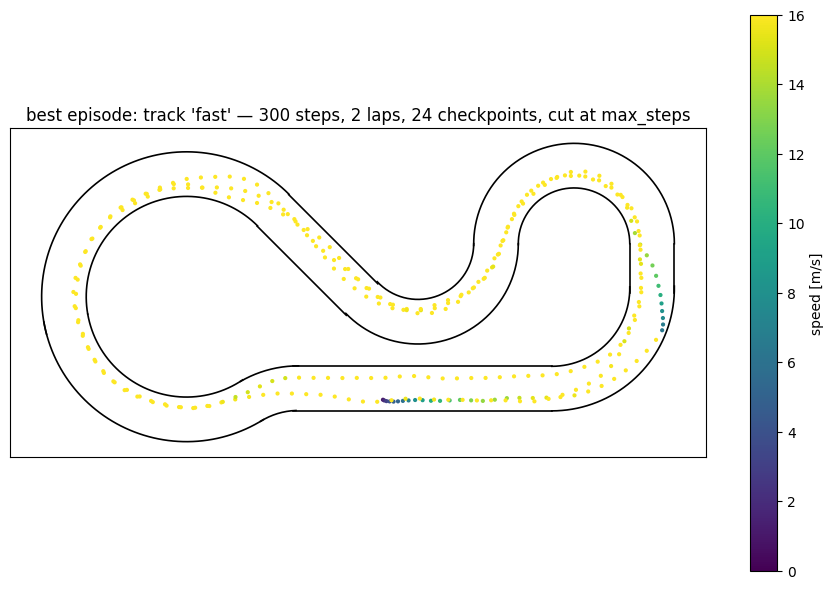

In [ ]:
import matplotlib.pyplot as plt

def plot_trajectory(model, config, seed, title="", max_steps=None, save_to=None):
    """Drive one deterministic episode (no rendering) and draw the ego path
    over the track corridor, coloured by speed.

    IMPORTANT: the figure only appears AFTER the episode finishes — up to
    duration*5 policy steps of model inference first. Progress is printed
    every 100 steps so a long episode doesn't look like a hang. Pass
    max_steps (e.g. 150) for a quick partial plot; pass save_to to also
    write a PNG (produced even if inline display is misconfigured)."""
    tenv = gym.make(ENV_ID, config=config)
    obs, _ = tenv.reset(seed=seed)
    u = tenv.unwrapped
    xs, ys, vs = [], [], []
    terminated = truncated = False
    while not (terminated or truncated) and (max_steps is None or len(xs) < max_steps):
        action, _ = model.predict(obs[np.newaxis], deterministic=True)
        obs, reward, terminated, truncated, _ = tenv.step(action[0])
        xs.append(float(u.vehicle.position[0]))
        ys.append(float(u.vehicle.position[1]))
        vs.append(float(u.vehicle.speed))
        if len(xs) % 100 == 0:
            print(f"  ...{len(xs)} steps, {u.lap_count} laps so far", flush=True)
    laps, ckpts, track = u.lap_count, u.checkpoint_count, u.active_track
    end = "terminated" if terminated else ("cut at max_steps" if not truncated else "time limit")

    fig, ax = plt.subplots(figsize=(9, 6))
    graph = u.road.network.graph
    for _from in graph:
        for _to in graph[_from]:
            lanes = graph[_from][_to]
            for k, lane in enumerate(lanes):
                s = np.linspace(0, lane.length, max(2, int(lane.length)))
                edges = []
                if k == 0:
                    edges.append(-lane.width / 2)     # corridor wall
                if k == len(lanes) - 1:
                    edges.append(+lane.width / 2)     # corridor wall
                for lat in edges:
                    pts = np.array([lane.position(si, lat) for si in s])
                    ax.plot(pts[:, 0], pts[:, 1], color="k", lw=1.2)
    sc = ax.scatter(xs, ys, c=vs, s=4, cmap="viridis",
                    vmin=0, vmax=config["speed_limit"])
    plt.colorbar(sc, ax=ax, label="speed [m/s]")
    ax.set_aspect("equal")
    ax.invert_yaxis()   # match the env's screen orientation
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{title}track '{track}' — {len(xs)} steps, {laps} laps, "
                 f"{ckpts} checkpoints, {end}")
    plt.tight_layout()
    if save_to is not None:
        fig.savefig(save_to, dpi=120)
        print(f"saved -> {save_to}")
    plt.show()
    tenv.close()

# Same seed as the recorded video -> same episode, drawn instead of filmed.
# max_steps keeps it quick; drop it to draw the whole episode.
plot_trajectory(trained_model, rec_config, seed=best_episode["seed"],
                title="best episode: ", max_steps=300,
                save_to=VIDEO_DIR / "trajectory.png")


In [45]:
# ── Trajectory plot as a VIDEO of its own drawing process ─────────
# # Replays how the plot above is generated: the red car marker advances
# through the SAME deterministic episode while the speed-coloured trail
# grows behind it, so you can watch the path being drawn point by point.
# The animation is saved as an mp4 to VIDEO_DIR and displayed inline.
# Works headless — no pygame/render backend needed, only ffmpeg.
import base64 as _tb64
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML as _tHTML, display as _tdisplay

try:
    import imageio_ffmpeg
    plt.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()
except ImportError:
    pass   # a system ffmpeg on PATH also works

def animate_trajectory(model, config, seed, title="", max_steps=None,
                       save_to=None, fps=15, stride=2):
    """Drive one deterministic episode (same collection as plot_trajectory),
    then render the plot-drawing process as a video: each frame adds the
    next `stride` policy steps to the trail (stride=2 -> 10x realtime at
    the 5 Hz decision rate). Progress prints every 100 steps, like the
    static plot, because inference happens before any frame is rendered."""
    tenv = gym.make(ENV_ID, config=config)
    obs, _ = tenv.reset(seed=seed)
    u = tenv.unwrapped
    xs, ys, vs = [], [], []
    terminated = truncated = False
    while not (terminated or truncated) and (max_steps is None or len(xs) < max_steps):
        action, _ = model.predict(obs[np.newaxis], deterministic=True)
        obs, reward, terminated, truncated, _ = tenv.step(action[0])
        xs.append(float(u.vehicle.position[0]))
        ys.append(float(u.vehicle.position[1]))
        vs.append(float(u.vehicle.speed))
        if len(xs) % 100 == 0:
            print(f"  ...{len(xs)} steps, {u.lap_count} laps so far", flush=True)
    xs, ys, vs = np.array(xs), np.array(ys), np.array(vs)
    laps, ckpts, track = u.lap_count, u.checkpoint_count, u.active_track

    fig, ax = plt.subplots(figsize=(9, 6))
    graph = u.road.network.graph          # corridor walls, as in the plot
    for _from in graph:
        for _to in graph[_from]:
            lanes = graph[_from][_to]
            for k, lane in enumerate(lanes):
                s = np.linspace(0, lane.length, max(2, int(lane.length)))
                lats = ([-lane.width / 2] if k == 0 else []) + \
                       ([lane.width / 2] if k == len(lanes) - 1 else [])
                for lat in lats:
                    pts = np.array([lane.position(si, lat) for si in s])
                    ax.plot(pts[:, 0], pts[:, 1], color="k", lw=1.2)
    trail = ax.scatter([], [], c=[], s=4, cmap="viridis",
                       vmin=0, vmax=config["speed_limit"])
    car, = ax.plot([], [], "o", color="red", ms=8, zorder=5)
    plt.colorbar(trail, ax=ax, label="speed [m/s]")
    ax.set_aspect("equal")
    ax.invert_yaxis()                     # match the env's screen orientation
    ax.set_xticks([]); ax.set_yticks([])
    title_base = f"{title}track '{track}' — {laps} laps, {ckpts} checkpoints"

    frames = int(np.ceil(len(xs) / stride))
    def _update(frame):
        n = min((frame + 1) * stride, len(xs))
        trail.set_offsets(np.column_stack([xs[:n], ys[:n]]))
        trail.set_array(vs[:n])
        car.set_data([xs[n - 1]], [ys[n - 1]])
        ax.set_title(f"{title_base}  [step {n}/{len(xs)}]")
        return trail, car
    anim = FuncAnimation(fig, _update, frames=frames, blit=False)
    if save_to is None:
        save_to = VIDEO_DIR / "trajectory_drawing.mp4"
    anim.save(save_to, writer=FFMpegWriter(fps=fps))
    plt.close(fig)
    tenv.close()
    print(f"saved -> {save_to}  ({frames} frames @ {fps} fps, "
          f"{frames / fps:.0f} s of video)")
    b64 = _tb64.b64encode(Path(save_to).read_bytes()).decode("ascii")
    _tdisplay(_tHTML(f'<video width="720" controls muted loop>'
                     f'<source src="data:video/mp4;base64,{b64}" '
                     f'type="video/mp4"></video>'))

# Same seed/config as the static plot above -> the same episode, replayed
# as a drawing video. Drop max_steps to animate the whole episode.
animate_trajectory(trained_model, rec_config, seed=best_episode["seed"],
                   title="best episode: ", max_steps=600,
                   save_to=VIDEO_DIR / "trajectory_drawing.mp4")

  ...100 steps, 0 laps so far
  ...200 steps, 1 laps so far
  ...300 steps, 2 laps so far
  ...400 steps, 3 laps so far
  ...500 steps, 4 laps so far
  ...600 steps, 5 laps so far
saved -> c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\trajectory_drawing.mp4  (300 frames @ 15 fps, 20 s of video)


## Display the Exported Video

In [ ]:
def show_video(video_path, width=720):
""Embed an exported mp4 directly in the notebook."""
    video_path = Path(video_path)
    video_bytes = video_path.read_bytes()
    encoded = base64.b64encode(video_bytes).decode("ascii")
    display(HTML(f"""
    <video width="{width}" controls>
      <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
    </video>
""))

if best_video_path is not None:
    show_video(best_video_path)
else:
    print("No video file was found. Check that moviepy/ffmpeg are installed and rerun the recording cell.")


## record video env

In [ ]:
from stable_baselines3.common.vec_env import VecVideoRecorder
def record_video(
    model_path: str | Path,
    video_dir:  str | Path,
    n_episodes: int  = 3,
    video_length: int = 300,   # steps per video, match your episode duration
):
""
    Load trained model and record n_episodes to mp4.
    Completely separate from training — no interaction with train_env.
""
    video_dir = Path(video_dir)
    video_dir.mkdir(parents=True, exist_ok=True)

    # Load model — device doesn't matter for inference, cpu is fine
    model = PPO.load(str(model_path), device="cpu")

    # Cap the episode to the recorded window: video_length steps at
    # policy_frequency (5 Hz). Default duration is 800 s = 4,000 steps,
    # which kept the loop running long after the recording stopped.
    rec_cfg = RacetrackFast.default_config().copy()
    rec_cfg["duration"] = video_length / rec_cfg["policy_frequency"]

    # Create a fresh env with rgb_array — NEVER reuse train_env here
    # rgb_array must be set at gym.make time; you cannot switch after creation
    record_env = DummyVecEnv([
        lambda: gym.make(ENV_ID, config=rec_cfg, render_mode="rgb_array")
    ])

    # Wrap with recorder — saves an mp4 every `video_length` steps
    record_env = VecVideoRecorder(
        record_env,
        video_folder = str(video_dir),
        record_video_trigger = lambda step: step == 0,  # start immediately
        video_length = video_length,
        name_prefix  = "racetrack_policy",
    )

    obs = record_env.reset()
    for episode in range(n_episodes):
        done  = False
        total = 0.0
        steps = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = record_env.step(action)
            total += float(reward[0])
            steps += 1

        print(f"Episode {episode+1}: {steps} steps, return={total:.2f}")
        obs = record_env.reset()

    record_env.close()
    print(f"Videos saved to {video_dir}")

In [44]:
def record_video_manual(
    model_path:  str | Path,
    output_path: str | Path,
    n_episodes:  int   = 1,
    fps:         int   = 15,    # match simulation_frequency
    resolution:  tuple = (600, 600),
):
    try:
        import cv2
    except ImportError:
        raise ImportError("pip install opencv-python")

    model  = PPO.load(str(model_path), device="cpu")
    output = Path(output_path)
    output.parent.mkdir(parents=True, exist_ok=True)

    cfg = RacetrackFast.default_config().copy()
    cfg["screen_width"]  = resolution[0]
    cfg["screen_height"] = resolution[1]

    # rgb_array must be at construction time — cannot change later
    env = gym.make(ENV_ID, config=cfg, render_mode="rgb_array")

    # OpenCV VideoWriter — mp4v codec is widely compatible
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = None

    for episode in range(n_episodes):
        obs, _ = env.reset()
        done = truncated = False
        total = 0.0

        while not (done or truncated):
            # Render BEFORE step so frame shows the state the policy saw
            frame = env.render()   # [H, W, 3] uint8 RGB

            if writer is None:
                h, w = frame.shape[:2]
                writer = cv2.VideoWriter(str(output), fourcc, fps, (w, h))

            # OpenCV uses BGR; convert from RGB
            writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

            action, _ = model.predict(obs[np.newaxis], deterministic=True)
            obs, reward, done, truncated, info = env.step(action[0])
            total += float(reward)

        print(f"Episode {episode+1}: return={total:.2f}")

    env.close()
    if writer:
        writer.release()
    print(f"Saved: {output}")

In [45]:
record_video(
    model_path  = BEST_MODEL_DIR / "phase2" / "best_model.zip",
    video_dir   = str(VIDEO_DIR),
    n_episodes  = 3,
    video_length= 300,
)

Saving video to c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-0-to-step-300.mp4
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-0-to-step-300.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-0-to-step-300.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-0-to-step-300.mp4
Episode 1: 300 steps, return=255.39
Saving video to c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-300-to-step-600.mp4
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-300-to-step-600.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-300-to-step-600.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-300-to-step-600.mp4
Episode 2: 300 steps, return=259.10
Saving video to c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-600-to-step-900.mp4
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-600-to-step-900.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-600-to-step-900.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-600-to-step-900.mp4
Episode 3: 300 steps, return=263.31
MoviePy - Building video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-900-to-step-1200.mp4.
MoviePy - Writing video c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-900-to-step-1200.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos\racetrack_policy-step-900-to-step-1200.mp4
Videos saved to c:\Users\16469\Desktop\circuit\racetrack-agents\runs\sb3_ppo_cnn_full\videos


## Optional: TensorBoard

Run this cell while training or after training to inspect reward, loss, entropy, KL, and evaluation curves.

In [46]:
# Uncomment these lines in an interactive notebook session.

